# 01 - Data Exploration
Goal: turn raw nflverse schedules into a clean, validated games table (2012–2025).

**Contents:** Setup · 1. Load and filter · 2. Grain · 3. Types and ordering ·
4. Coverage · 5. Validity · 6. Team abbreviations · 7. Completeness ·
8. Clean table · 9. Distributions · Decisions · Open questions

## Setup

In [1]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load and filter

In [2]:
raw = nfl.load_schedules().to_pandas()
raw.shape
raw.columns

Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium'],
      dtype='str')

In [3]:
def filter_seasons(df, first=2012, last = 2025):
    """Return rows whose season is between first and last, inclusive"""
    return df[df["season"].between(first, last)]

games = filter_seasons(raw).copy()
games.shape

(3829, 46)

## 2. Grain

In [4]:
n_dupes = games["game_id"].duplicated().sum()
print(f"Duplicate game_ids: {n_dupes}")
assert n_dupes == 0, "Duplicate game_ids found"

Duplicate game_ids: 0


## 3. Types and ordering

In [5]:
"""
The gameday and gametime columns are joined together as a real datetime under the new 
column "Kickoff." The values in the dataframe are sorted and renumbered. 
"""
games["Kickoff"] = pd.to_datetime(games["gameday"] + " " + games["gametime"])
games = games.sort_values("Kickoff").reset_index(drop=True)
games[["game_id", "week", "Kickoff"]].head(10)


,game_id,week,Kickoff
0,2012_01_DAL_NYG,1,2012-09-05 20:30:00
1,2012_01_IND_CHI,1,2012-09-09 13:00:00
2,2012_01_PHI_CLE,1,2012-09-09 13:00:00
3,2012_01_STL_DET,1,2012-09-09 13:00:00
4,2012_01_MIA_HOU,1,2012-09-09 13:00:00
5,2012_01_ATL_KC,1,2012-09-09 13:00:00
6,2012_01_JAX_MIN,1,2012-09-09 13:00:00
7,2012_01_WAS_NO,1,2012-09-09 13:00:00
8,2012_01_BUF_NYJ,1,2012-09-09 13:00:00
9,2012_01_NE_TEN,1,2012-09-09 13:00:00


In [6]:
weeks_in_order = games.groupby("season")["week"].is_monotonic_increasing.all()
print(f"Weeks never go backward within a season: {weeks_in_order}")
assert weeks_in_order

Weeks never go backward within a season: True


## 4. Coverage

In [7]:
counts = pd.crosstab(games["season"], games["game_type"])
counts

game_type,CON,DIV,REG,SB,WC
season,,,,,
2012,2,4,256,1,4
2013,2,4,256,1,4
2014,2,4,256,1,4
2015,2,4,256,1,4
2016,2,4,256,1,4
2017,2,4,256,1,4
2018,2,4,256,1,4
2019,2,4,256,1,4
2020,2,4,256,1,6


- This table reveals 3 items to note: 
    1. The playoff team expansion in 2020, increasing the number of WC games to 6
    2. The 17-game-schedule expansion in 2021, increasing the REG game count to 272
    3. Only 271 games in 2022 due to the no-contest ruling of the Bengals-Bills game in which Damar Hamlin suffered a severe injury

In [8]:
# Win percent of the home team in the regular season vs. playoff
games["Is_Playoff"] = games["game_type"] != "REG"
games["Home_Win"] = (games["result"] > 0).astype(int)
print(games.groupby("Is_Playoff")["Home_Win"].count())
print(games.groupby("Is_Playoff")["Home_Win"].mean())

Is_Playoff
False    3663
True      166
Name: Home_Win, dtype: int64
Is_Playoff
False    0.551188
True     0.626506
Name: Home_Win, dtype: float64


**Finding:** In all games (neutral sites included), home teams won 55.1% of 3663 regular season games and 62.7% of 166 playoff games. The playoff sample is small, so the gap is suggestive rather than conclusive. Playoff home field goes to the higher seed, so part of the gap likely reflects team strenth rather than home advantage. 

**Decision (provisional):**
- Include playoff games in Elo rating updates. 
- Apply home-feild advantage to playoff games at the higher seed's stadium
- Estiamte the size of home-feild advantage from regular season, non-nuetral games only, where the balanced schedule measn home and away teams are equally strong on average. 
- Revisit in Phase 1: tune with and without playoff games and compare Brier scores. 

## 5. Validity

In [9]:
# Check the results column
calc_result = games["home_score"] - games["away_score"]
mismatches = (games["result"] != calc_result).sum()
print(f"result mismatches: {mismatches}")
assert mismatches == 0, "result != home_score - away_score"

result mismatches: 0


In [10]:
# Check the total column
calc_total = games["home_score"] + games["away_score"]
total_mismatch = (games["total"] != calc_total).sum()
print(f"total mismatches: {total_mismatch}")
assert total_mismatch == 0, "total != home_score + away_score"

total mismatches: 0


In [11]:
# Check the number of ties
ties = games[games["result"] == 0]
print(ties[["game_id", "season", "home_team", "away_team", "home_score"]])
print(len(ties))

              game_id  season home_team away_team  home_score
143    2012_10_STL_SF    2012        SF       STL        24.0
437    2013_12_MIN_GB    2013        GB       MIN        26.0
616   2014_06_CAR_CIN    2014       CIN       CAR        37.0
1173  2016_07_SEA_ARI    2016       ARI       SEA         6.0
1176  2016_08_WAS_CIN    2016       CIN       WAS        27.0
1608  2018_01_PIT_CLE    2018       CLE       PIT        21.0
1625   2018_02_MIN_GB    2018        GB       MIN        29.0
1881  2019_01_DET_ARI    2019       ARI       DET        27.0
2170  2020_03_CIN_PHI    2020       PHI       CIN        23.0
2543  2021_10_DET_PIT    2021       PIT       DET        16.0
2694  2022_01_IND_HOU    2022       HOU       IND        20.0
2872  2022_13_WAS_NYG    2022       NYG       WAS        20.0
3605   2025_04_GB_DAL    2025       DAL        GB        40.0
13


In [12]:
games["location"].value_counts()
neutral = games[games["location"] == "Neutral"]
pd.crosstab(neutral["season"], neutral["game_type"])

game_type,REG,SB,WC
season,,,
2012,1,1,0
2013,3,1,0
2014,4,1,0
2015,3,1,0
2016,4,1,0
2017,5,1,0
2018,3,1,0
2019,5,1,0
2020,3,1,0


In [13]:
home_fav_spread = games["spread_line"] > 0
home_fav_ml = games["home_moneyline"] < 0
pd.crosstab(home_fav_spread, home_fav_ml)

home_moneyline,False,True
spread_line,,
False,1346,67
True,1,2415


In [14]:
disagree = games[(games["spread_line"] <= 0) & (games["home_moneyline"] < 0)]
disagree["spread_line"].value_counts()

spread_line
-1.0    58
-1.5     6
-0.0     3
Name: count, dtype: int64

### Spread sign check

**Finding:** `spread_line` agrees with the moneyline favorite in 98% of games
(3,761 of 3,829). A positive `spread_line` means the home team is favored.
It is the market's expected home margin, on the same scale and sign as `result`.

- **67 games** have `spread_line <= 0` but a negative home moneyline:
  [what you found, e.g., "mostly pick'em games with a spread of 0"].
- **1 game** has a positive `spread_line` but a non-negative home moneyline:
  [game_id, spread, and both moneylines].
- **Known-game check:** [game you remember, e.g., "In `2023_xx_AWAY_HOME`, HOME was
  favored by X and `spread_line` = +X"], which confirms the convention.

**Gotcha:** sportsbooks display a home favorite as a negative number ("home −3");
nflverse stores the same line as `spread_line = 3`.

**Use:**
- The home team covers when `result > spread_line`.
- `result - spread_line` is the market's error on each game (see section 9).
- The margin model's predicted μ is directly comparable to `spread_line`.

- **1 game** (`2017_04_CHI_GB`) has a positive spread but a missing moneyline;
  see "Missing moneylines" in section 7.

## 6. Team Abbreviations

In [15]:
print(games["home_team"].unique())

<ArrowStringArray>
['NYG', 'CHI', 'CLE', 'DET', 'HOU',  'KC', 'MIN',  'NO', 'NYJ', 'TEN', 'ARI',
  'GB',  'TB', 'DEN', 'BAL', 'OAK', 'BUF', 'CAR', 'CIN', 'IND', 'JAX', 'MIA',
  'NE', 'PHI', 'SEA', 'STL', 'PIT',  'SD',  'SF', 'ATL', 'DAL', 'WAS',  'LA',
 'LAC',  'LV']
Length: 35, dtype: str


In [16]:
team_mapping = {'OAK': 'LV', 'STL': 'LA', 'SD': 'LAC'}
games["home_team"] , games["away_team"] = games["home_team"].replace(team_mapping), games["away_team"].replace(team_mapping)

In [17]:
all_teams = pd.concat([games["home_team"], games["away_team"]]).unique()
print(len(all_teams))
assert len(all_teams) == 32

32


## 7. Completeness

In [18]:
games.columns

Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'Kickoff', 'Is_Playoff', 'Home_Win'],
      dtype='str')

In [19]:
keep = ["game_id", "season", "game_type", "week", "home_team", "away_team", "home_score", 
        "away_score", "result", "location", "spread_line", "home_moneyline", 
        "away_moneyline", "home_rest", "away_rest", "home_qb_id", "away_qb_id", 
        "Kickoff"]
games[keep].isna().sum()

game_id           0
season            0
game_type         0
week              0
home_team         0
away_team         0
home_score        0
away_score        0
result            0
location          0
spread_line       0
home_moneyline    1
away_moneyline    1
home_rest         0
away_rest         0
home_qb_id        0
away_qb_id        0
Kickoff           0
dtype: int64

In [20]:
games[games["home_moneyline"].isna()][keep]

,game_id,season,game_type,week,home_team,away_team,home_score,away_score,result,location,spread_line,home_moneyline,away_moneyline,home_rest,away_rest,home_qb_id,away_qb_id,Kickoff
1382,2017_04_CHI_GB,2017,REG,4,GB,CHI,35.0,14.0,21.0,Home,7.5,NaN,NaN,4,4,00-0023459,00-0030520,2017-09-28 20:25:00


### Missing moneylines

**Finding:** One game is missing both moneylines: `2017_04_CHI_GB`
(Week 4, Thursday night, Bears at Packers, GB won 35–14). Its `spread_line`
is present (+7.5, GB favored), so only the moneylines are missing.

This is also the single "disagreement" game in the spread-sign crosstab:
`NaN < 0` evaluates to False, so a missing moneyline looked like "home not
favored." It is missing data, not a real conflict.

**Decision:**
- Keep the game in the clean table. Elo and the margin model only need scores.
- Exclude it from moneyline-based calculations (no-vig probabilities, bankroll).
  It is in a training season (2017), so the 2022–2025 market benchmark is unaffected.
- Do not fill in a value; one game out of 3,829 isn't worth adding an assumption.

## 8. Clean Table

### 8a. Rename to lowercase

In [21]:
# Match column names to nflverse's snake_case style
games = games.rename(columns = {"Kickoff": "kickoff", "Is_Playoff": "is_playoff"})

### 8b. Derived columns

In [22]:
# Neutral-site flag: no-homefield advantage for these games
games["is_neutral"] = games["location"] == "Neutral"

# Home result as Elo's S value: 1=win, 0.5=tie, 0=loss
games["home_win"] = (games["result"] > 0) * 1.0 + (games["result"] == 0) * 0.5

# Remove the earlier version, which counted ties as losses
games = games.drop(columns = ["Home_Win"])

games["home_win"].value_counts()

home_win
1.0    2123
0.0    1693
0.5      13
Name: count, dtype: int64

### 8c. Score to integers

In [23]:
score_cols = ["home_score", "away_score", "result"]
games[score_cols] = games[score_cols].astype(int)

In [24]:
clean_cols = [
    # identity and timing
    "game_id", "season", "week", "kickoff", "game_type", "is_playoff",
    # teams and venue
    "home_team", "away_team", "location", "is_neutral",
    # outcome
    "home_score", "away_score", "result", "home_win",
    # context
    "home_rest", "away_rest", "home_qb_id", "away_qb_id",
    # market
    "spread_line", "home_moneyline", "away_moneyline",
]

clean = games[clean_cols].copy()
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3829 entries, 0 to 3828
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   game_id         3829 non-null   str           
 1   season          3829 non-null   int32         
 2   week            3829 non-null   int32         
 3   kickoff         3829 non-null   datetime64[us]
 4   game_type       3829 non-null   str           
 5   is_playoff      3829 non-null   bool          
 6   home_team       3829 non-null   str           
 7   away_team       3829 non-null   str           
 8   location        3829 non-null   str           
 9   is_neutral      3829 non-null   bool          
 10  home_score      3829 non-null   int64         
 11  away_score      3829 non-null   int64         
 12  result          3829 non-null   int64         
 13  home_win        3829 non-null   float64       
 14  home_rest       3829 non-null   int32         
 15  away_rest      

### 8e. Assert the contract

In [25]:
# One row per game, 2012–2025
assert len(clean) == 3829, "Unexpected number of games"
assert not clean["game_id"].duplicated().any(), "Duplicate game_ids"

# 32 franchises after standardizing abbreviations
teams = pd.concat([clean["home_team"], clean["away_team"]]).unique()
assert len(teams) == 32, f"Expected 32 teams, found {len(teams)}"

# Outcome columns are complete
assert clean[score_cols].notna().all().all(), "Missing scores or results"

# home_win only takes Elo's three S values
assert clean["home_win"].isin([0, 0.5, 1]).all(), "Unexpected home_win value"

# Only the one known game is missing moneylines
assert clean["home_moneyline"].isna().sum() == 1, "New missing moneylines appeared"

print("All checks passed")

All checks passed


### 8f. Save it

In [26]:
from pathlib import Path

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

clean.to_parquet(data_dir / "games_clean.parquet", index=False)
print(f"Saved {len(clean)} games to {data_dir / "games_clean.parquet"}")

Saved 3829 games to ../data/games_clean.parquet


### Data dictionary: `games_clean`

One row per game, 2012–2025 regular season and playoffs (3,829 games), sorted by kickoff.

| Column | Type | Meaning | Notes |
| --- | --- | --- | --- |
| `game_id` | text | unique game key | keeps original abbreviations (e.g., `2012_01_STL_DET`) |
| `season` | int | NFL season year | a season's playoffs are played in the following January/February |
| `week` | int | week of the season | playoff weeks continue the numbering |
| `kickoff` | datetime | scheduled start time | US Eastern |
| `game_type` | text | REG, WC, DIV, CON, SB | |
| `is_playoff` | bool | True for any non-REG game | |
| `home_team` | text | home team abbreviation | OAK→LV, SD→LAC, STL→LA standardized |
| `away_team` | text | away team abbreviation | same standardization |
| `location` | text | Home or Neutral | |
| `is_neutral` | bool | neutral-site game | no home-field advantage applied |
| `home_score` | int | home team points | |
| `away_score` | int | away team points | |
| `result` | int | home score − away score | target for the margin model |
| `home_win` | float | 1 win, 0.5 tie, 0 loss | S in the Elo update |
| `home_rest` | int | home team days since last game | |
| `away_rest` | int | away team days since last game | |
| `home_qb_id` | text | home starting QB (nflverse ID) | |
| `away_qb_id` | text | away starting QB (nflverse ID) | |
| `spread_line` | float | market's expected home margin | positive = home favored; sportsbooks display the opposite sign |
| `home_moneyline` | float | home odds (American) | missing for `2017_04_CHI_GB` |
| `away_moneyline` | float | away odds (American) | missing for `2017_04_CHI_GB` |

## 9. Distributions

### 9a. Histogram of the result column

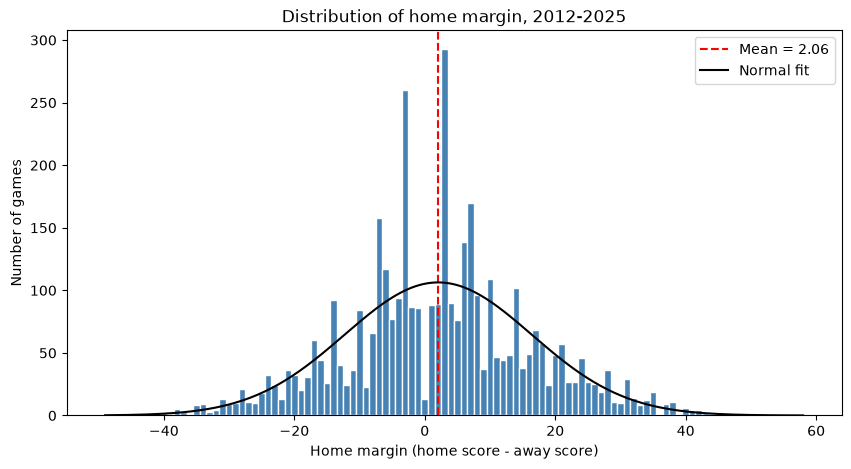

Mean: 2.06
Standard Deviation: 14.36


In [27]:
# Home margin for every game
margins = clean["result"]

# one bin per point 
bins = np.arange(margins.min() - 0.5, margins.max() + 1.5, 1)

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(margins, bins=bins, color='steelblue', edgecolor='white')

# Mark the mean
ax.axvline(margins.mean(), color='red', linestyle='--', label=f"Mean = {margins.mean():.2f}")

ax.set_xlabel("Home margin (home score - away score)")
ax.set_ylabel("Number of games")
ax.set_title("Distribution of home margin, 2012-2025")

x = np.linspace(margins.min(), margins.max(), 400)
mu, sigma = margins.mean(), margins.std()
normal = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

# Scale the curve from a density to game counts (bin width = 1)
ax.plot(x, normal * len(margins), color="black", label="Normal fit")

ax.legend()
plt.show()

print(f"Mean: {margins.mean():.2f}")
print(f"Standard Deviation: {margins.std():.2f}")

In [28]:
reg_home = clean[~clean["is_playoff"] & ~clean["is_neutral"]]
print(f"HFA estimate (regular season, true home games): {reg_home['result'].mean():.2f} points")

HFA estimate (regular season, true home games): 1.98 points


### 9b. Line chart of the home margin by season

In [29]:
reg_home = clean[~clean["is_playoff"] & ~clean["is_neutral"]]
reg_home.shape

(3606, 21)

In [30]:
by_season = reg_home.groupby("season").agg(
    avg_margin = ("result", "mean"),
    home_win_rate = ("home_win", "mean"),
    games = ("result", "count"),
)
by_season

,avg_margin,home_win_rate,games
season,,,
2012,2.592157,0.574510,255
2013,3.252964,0.602767,253
2014,2.543651,0.573413,252
2015,1.482213,0.537549,253
2016,2.595238,0.577381,252
2017,2.501992,0.569721,251
2018,2.343874,0.604743,253
2019,-0.047809,0.519920,251
2020,0.138340,0.503953,253


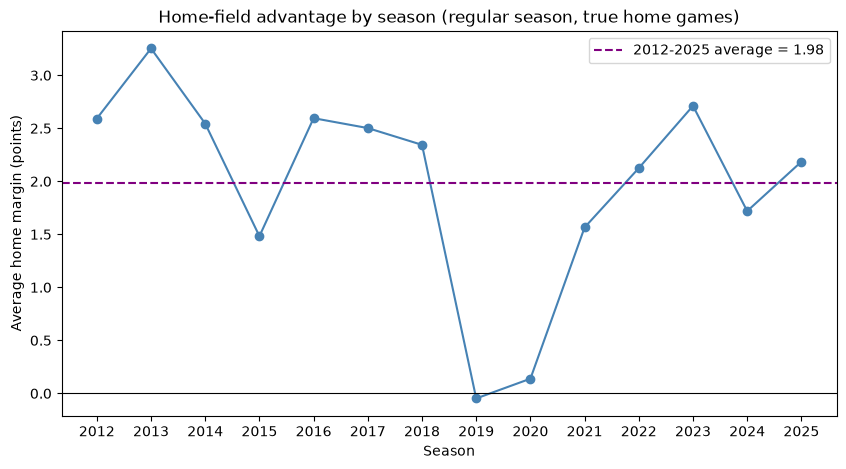

In [31]:
fig, ax = plt.subplots(figsize = (10,5))

ax.plot(by_season.index, by_season["avg_margin"], marker='o', color='steelblue')

#Reference lines
ax.axhline(reg_home["result"].mean(), color='purple', linestyle='--',
           label=f"2012-2025 average = {reg_home["result"].mean():.2f}")
ax.axhline(0, color='black',linewidth=0.8)

ax.set_xlabel("Season")
ax.set_ylabel("Average home margin (points)")
ax.set_title("Home-field advantage by season (regular season, true home games)")
ax.set_xticks(by_season.index)
ax.legend()
plt.show()

In [32]:
typical_noise = reg_home["result"].std() / np.sqrt(by_season["games"].mean())
print(f"Typical season-to-season noise (1 std. error): ±{typical_noise:.2f} points")

Typical season-to-season noise (1 std. error): ±0.90 points


In [33]:
def era(season):
    if season < 2020:
        return "2012–2019"
    elif season == 2020:
        return "2020 (no fans)"
    else:
        return "2021–2025"

reg_home.groupby(reg_home["season"].apply(era))["result"].agg(["mean", "std", "count"])

,mean,std,count
season,,,
2012–2019,2.159901,14.469851,2020
2020 (no fans),0.138340,14.295098,253
2021–2025,2.060015,14.218247,1333


### 9c. The market's error

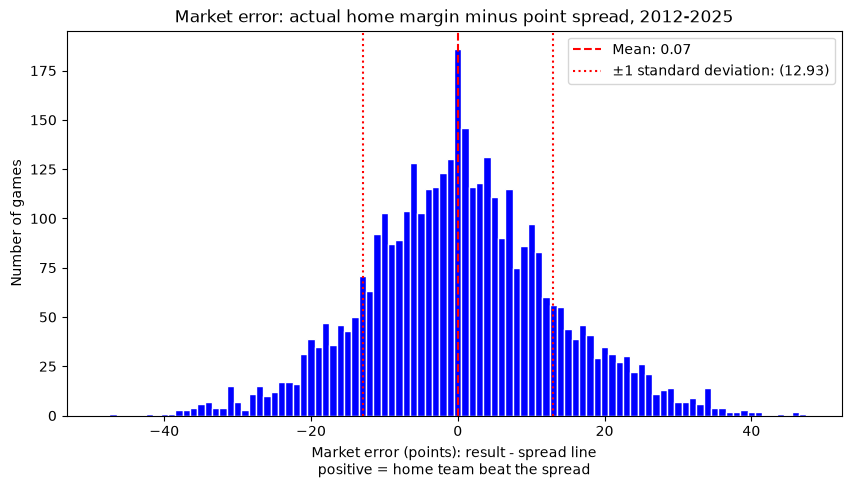

In [34]:
spread_margins = games["result"] - games["spread_line"]

bins = np.arange(spread_margins.min() - 1, spread_margins.max() + 1, 1)

fig, ax = plt.subplots(figsize = (10,5))
ax.hist(spread_margins, bins = bins, color = 'blue', edgecolor = 'white')

ax.axvline(spread_margins.mean(), color = 'red', linestyle = '--', label = f"Mean: {spread_margins.mean():.2f}")
ax.axvline(spread_margins.mean() - spread_margins.std(), color = 'red', linestyle = ":")
ax.axvline(spread_margins.mean() + spread_margins.std(), color = 'red', linestyle = ":",
           label = f"±1 standard deviation: ({spread_margins.std():.2f})")

ax.set_xlabel("Market error (points): result - spread line\n"
              "positive = home team beat the spread")
ax.set_ylabel("Number of games")
ax.set_title("Market error: actual home margin minus point spread, 2012-2025")

ax.legend()
plt.show()

### How to read this chart

Each bar counts games by how far the actual home margin (`result`) landed from the
market's prediction (`spread_line`). A value of **0** means the game finished exactly
on the spread. **Positive** values mean the home team did better than the market
expected (beat the spread); **negative** values mean it did worse.

- **Red dashed line (mean):** the market's average bias. A mean near 0 means the
  spread doesn't systematically favor home or away teams.
- **Gray dotted lines (±1 SD):** about two-thirds of games land between these lines,
  if errors are roughly normal. The width of this band is how uncertain a game
  still is *after* knowing the spread.
- **Spikes:** as with raw margins, bars near ±3 and ±7 stand out because scoring
  comes in field goals and touchdowns.

**Finding:** The market's error has a mean of 0.07 points (essentially unbiased) and a
standard deviation of 12.93 points. 